In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import torch

DATA_DIR = Path("data")
TORONTO = DATA_DIR / Path("toronto")
TIMIT = DATA_DIR / Path("timit")

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [3]:
if not TORONTO.exists():
    !bash load_toronto.sh
    
if not TIMIT.exists():
    !bash load_timit.sh

## EDA

In [4]:
import librosa

toronto_sr = pd.Series(
    [librosa.get_samplerate(f) for f in TORONTO.rglob("*.wav")]
).value_counts()

timit_sr = pd.Series(
    [librosa.get_samplerate(f) for f in TIMIT.rglob("*.wav")]
).value_counts()

print(toronto_sr) # 44100
print(timit_sr) # 16000


44100    18303
Name: count, dtype: int64
16000    6300
Name: count, dtype: int64


In [5]:
TORONTO_SR = 44100
TIMIT_SR = 16000

In [6]:
labels = pd.read_json(TORONTO / "labels.jsonl", lines=True)

labels["dataset/toronto_0/toronto_0_0.wav"][0]

'Терміново! Загроза нового вторгнення в Україну нині дуже висока.'

In [7]:
toronto_ids = [f.name for f in TORONTO.glob("toronto_*")]

toronto_test_ids = set(['toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89', 'toronto_43',
'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7', 'toronto_123', 'toronto_54', 'toronto_67',
'toronto_62', 'toronto_81', 'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
'toronto_58'])

toronto_train_ids = set(toronto_ids) - set(toronto_test_ids)
print(f"intersection is 0: {len(toronto_test_ids & toronto_train_ids) == 0}")

toronto_df = []
for f in TORONTO.rglob("*.wav"):
    toronto_df.append({
        "filename": f.name,
        "speaker_id": f.parent.name,
        "duration": librosa.get_duration(path=f, sr=TORONTO_SR),
        "label": labels[f"dataset/{f.parent.name}/{f.name}"][0]
    })
toronto_df = pd.DataFrame(toronto_df)

toronto_train_df = toronto_df[toronto_df["speaker_id"].isin(toronto_train_ids)]
toronto_test_df  = toronto_df[toronto_df["speaker_id"].isin(toronto_test_ids)]

missing_labels = toronto_df[toronto_df["label"] == ""] # 93 entries that probably should be removed from the test/training datasets
missing_labels_train = toronto_train_df[toronto_train_df["label"] == ""] # 72 from train part



intersection is 0: True


In [8]:
import matplotlib.pyplot as plt

def plot_toronto_distributions(df, title_prefix=""):
    _, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(df["duration"], bins=40, edgecolor="black")
    axes[0].set_title(f"{title_prefix} duration distribution")
    axes[0].set_xlabel("duration (seconds)")
    axes[0].set_ylabel("number of files")

    word_counts = df["label"].fillna("").str.split().str.len()
    axes[1].hist(word_counts, bins=40, edgecolor="black")
    axes[1].set_title(f"{title_prefix} words per label")
    axes[1].set_xlabel("word count")
    axes[1].set_ylabel("number of files")

    files_per_speaker = df["speaker_id"].value_counts()
    axes[2].hist(files_per_speaker, bins=40, edgecolor="black")
    axes[2].set_title(f"{title_prefix} files per speaker")
    axes[2].set_xlabel("files per speaker")
    axes[2].set_ylabel("number of speakers")

    plt.tight_layout()
    plt.show()

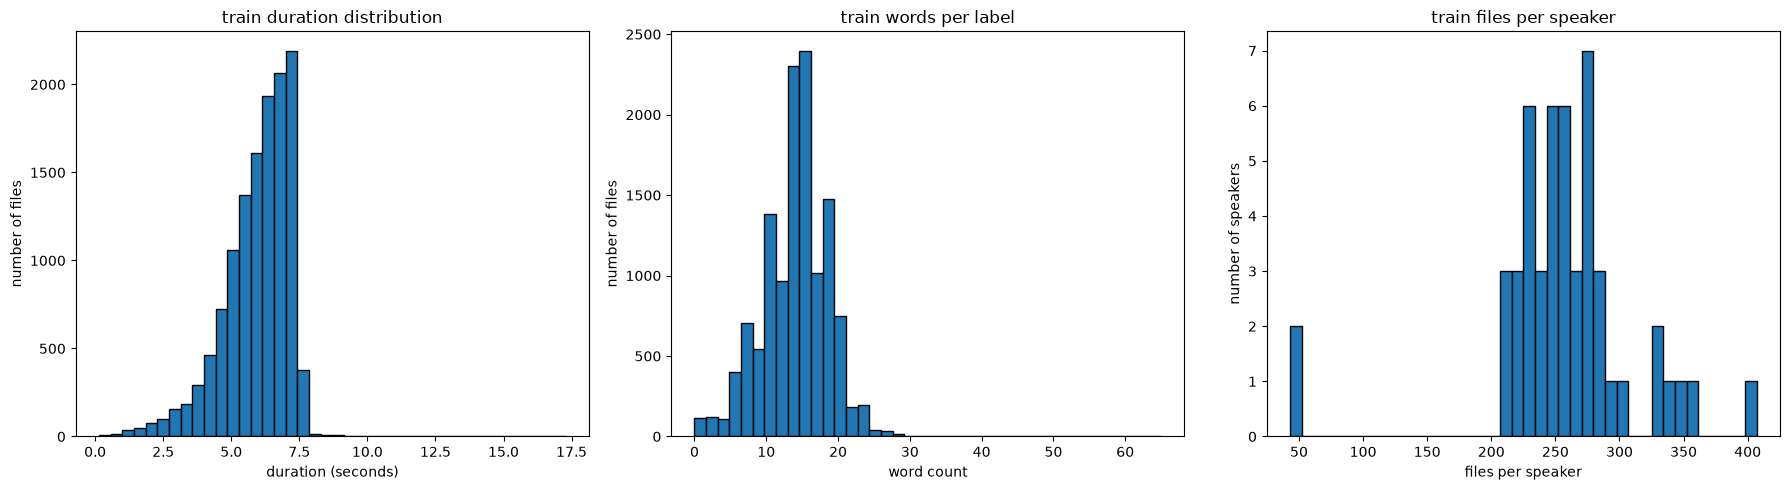

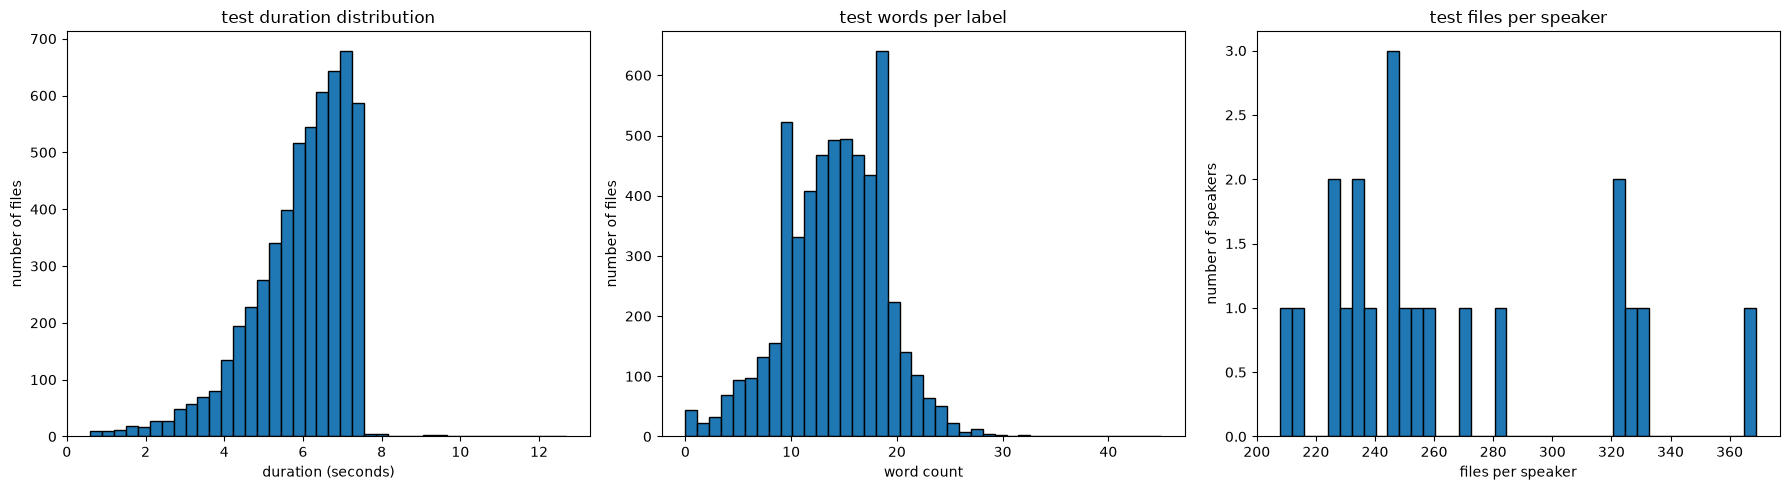

In [9]:
plot_toronto_distributions(toronto_train_df, "train")
plot_toronto_distributions(toronto_test_df, "test")

In [19]:
TIMIT_META_TEST = TIMIT / "test_data.csv"
TIMIT_META_TRAIN = TIMIT / "train_data.csv"

TIMIT_TEST = TIMIT / "data/test"
TIMIT_TRAIN = TIMIT / "data/train"

timit_train_meta = pd.read_csv(TIMIT_META_TRAIN)
timit_test_meta  = pd.read_csv(TIMIT_META_TEST)

timit_train_meta.head()

def build_timit_df(meta):
    audio = meta[meta["is_converted_audio"] == True]

    timit_df = []
    for _, row in audio.iterrows():
        wav = TIMIT / "data" / row["path_from_data_dir"]
        phn = wav.with_name(row["filename"].replace(".WAV.wav", ".PHN"))
        phonemes = [line.split()[2] for line in phn.read_text().splitlines()]
        timit_df.append({
            "path": str(wav),
            "filename": row["filename"],
            "speaker_id": row["speaker_id"],
            "dialect_region": row["dialect_region"],
            "sentence_type": row["filename"][:2],
            "duration": librosa.get_duration(path=wav, sr=TIMIT_SR),
            "gender": row["speaker_id"][0],
            "phonemes": phonemes,
        })
    return pd.DataFrame(timit_df)

timit_train_df = build_timit_df(timit_train_meta)
timit_test_df  = build_timit_df(timit_test_meta)

print(len(timit_train_df))
print(len(timit_test_df))


4620
1680


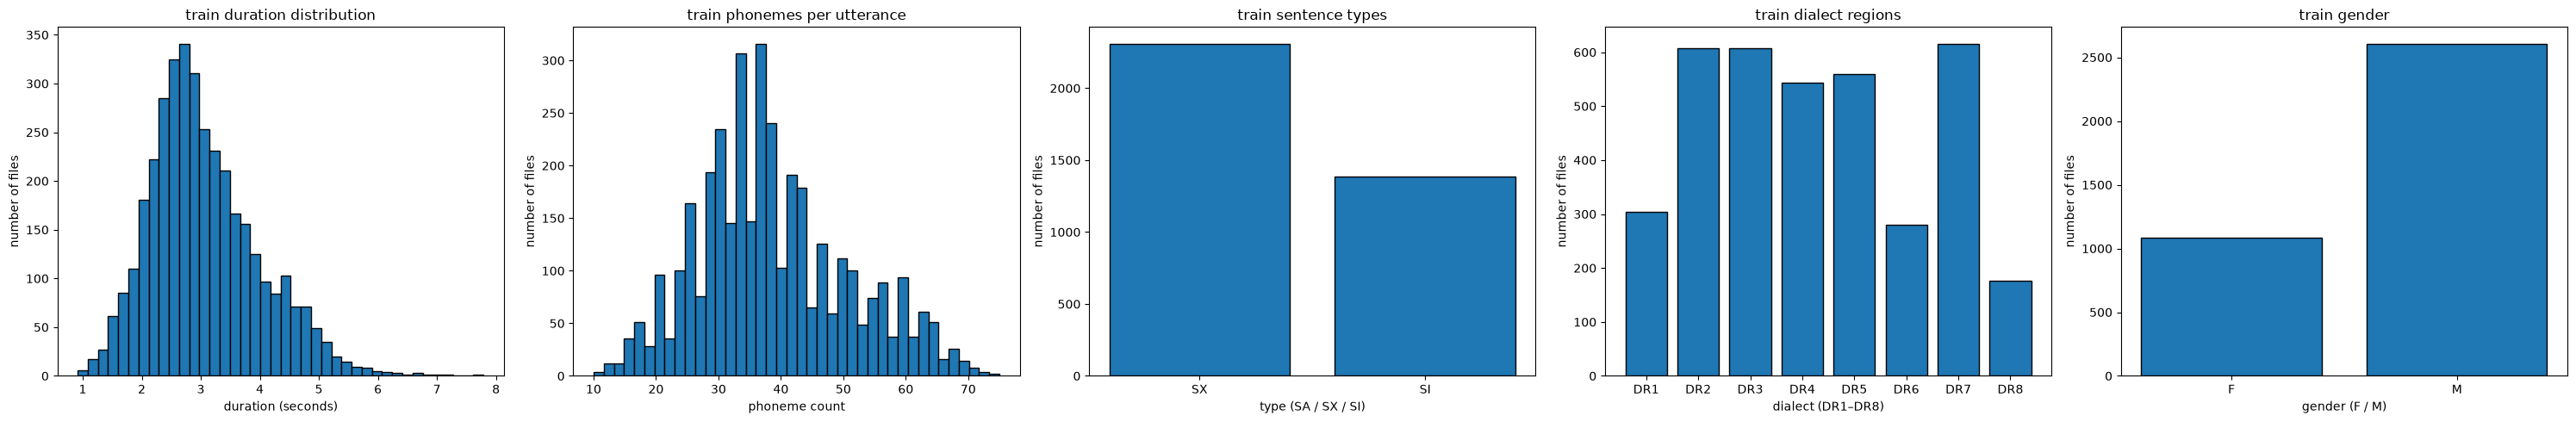

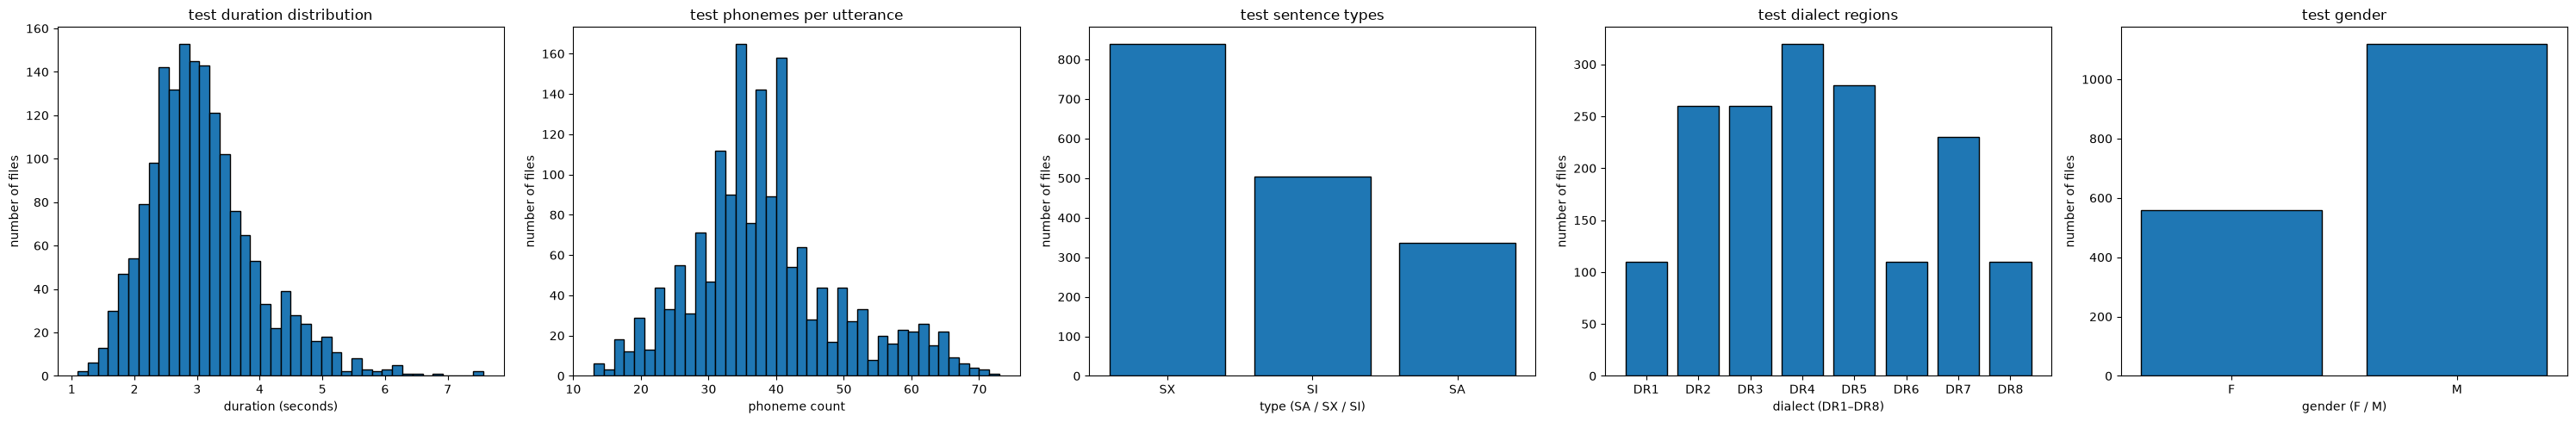

In [ ]:
def plot_timit_distributions(df, title_prefix=""):
    _, axes = plt.subplots(1, 5, figsize=(30, 5))

    axes[0].hist(df["duration"], bins=40, edgecolor="black")
    axes[0].set_title(f"{title_prefix} duration distribution")
    axes[0].set_xlabel("duration (seconds)")
    axes[0].set_ylabel("number of files")

    phoneme_counts = df["phonemes"].str.len()
    axes[1].hist(phoneme_counts, bins=40, edgecolor="black")
    axes[1].set_title(f"{title_prefix} phonemes per utterance")
    axes[1].set_xlabel("phoneme count")
    axes[1].set_ylabel("number of files")

    sentence_types = df["sentence_type"].value_counts()
    axes[2].bar(sentence_types.index, sentence_types.values, edgecolor="black")
    axes[2].set_title(f"{title_prefix} sentence types")
    axes[2].set_xlabel("type (SA / SX / SI)")
    axes[2].set_ylabel("number of files")

    dialects = df["dialect_region"].value_counts().sort_index()
    axes[3].bar(dialects.index, dialects.values, edgecolor="black")
    axes[3].set_title(f"{title_prefix} dialect regions")
    axes[3].set_xlabel("dialect (DR1–DR8)")
    axes[3].set_ylabel("number of files")

    genders = df["gender"].value_counts().sort_index()
    axes[4].bar(genders.index, genders.values, edgecolor="black")
    axes[4].set_title(f"{title_prefix} gender")
    axes[4].set_xlabel("gender (F / M)")
    axes[4].set_ylabel("number of files")

    plt.tight_layout()
    plt.show()
    
plot_timit_distributions(timit_train_df, "train")
plot_timit_distributions(timit_test_df, "test")

we are removing the SA data from train/val split, 2 sentanses are read by all of the speakers, what will result in the data leakage.  
split by speaker, stratification by dialect, train will use both SX and SI data, while val only SI data. it will prevent sentance leakage. (in SI 1 sentance is read by 1 speaker, in SX one sentance is read by multiple)

## Train/validation split

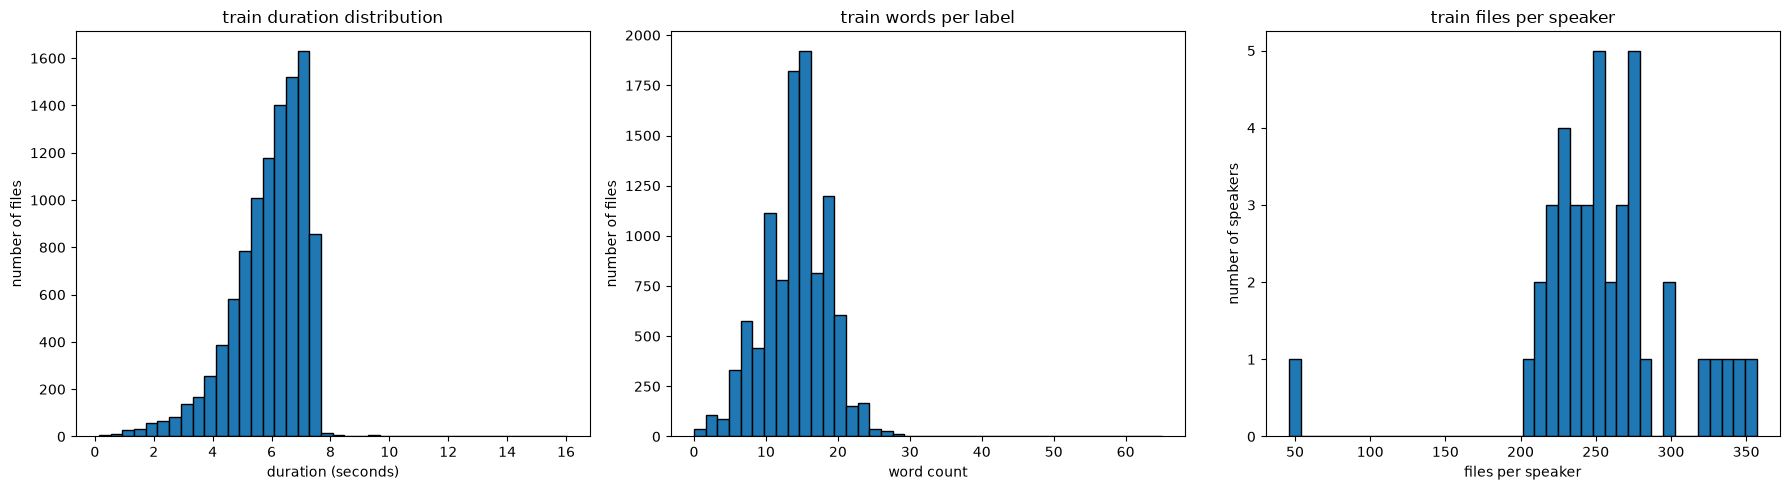

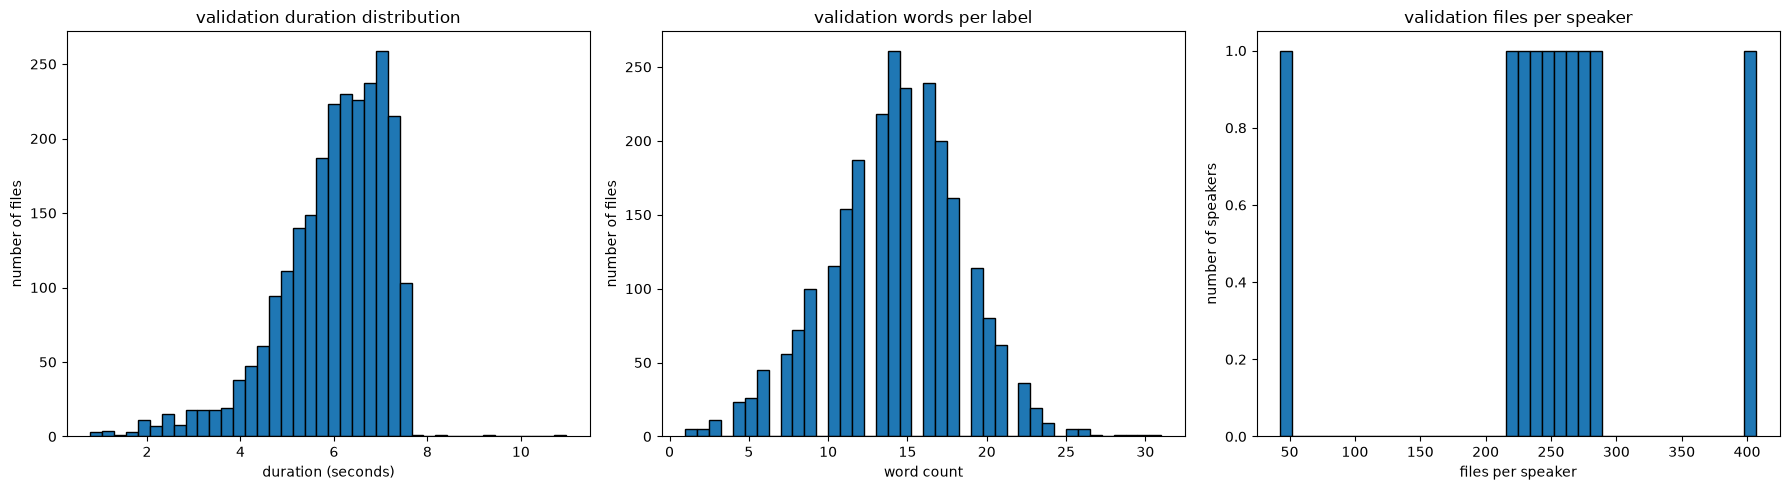

In [12]:
from sklearn.model_selection import GroupKFold

toronto_train_df = toronto_train_df[toronto_train_df["label"] != ""]

gkf = GroupKFold(n_splits=5)
train, val = next(gkf.split(toronto_train_df, groups=toronto_train_df["speaker_id"]))
toronto_tr_df, toronto_val_df = toronto_train_df.iloc[train], toronto_train_df.iloc[val]

plot_toronto_distributions(toronto_tr_df, "train")
plot_toronto_distributions(toronto_val_df, "validation")

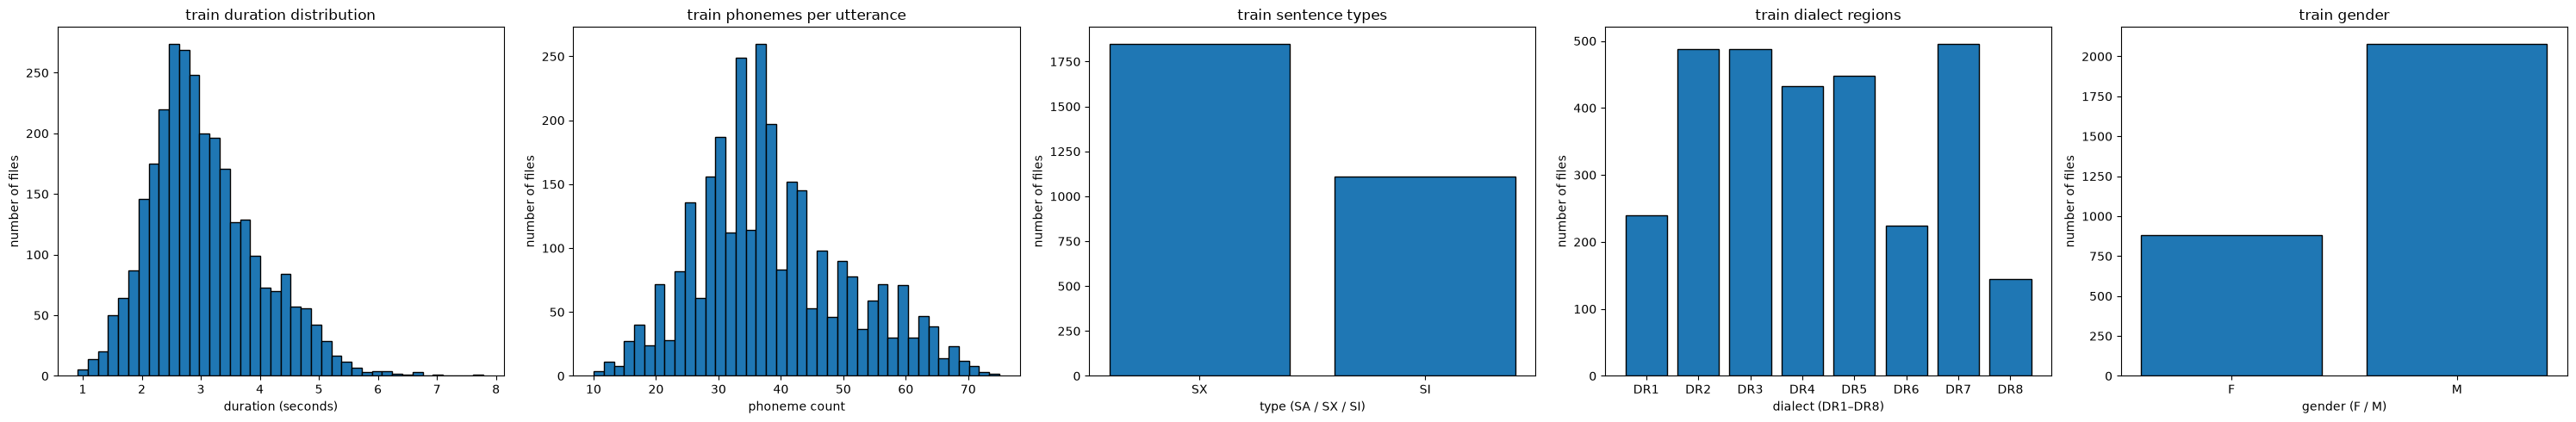

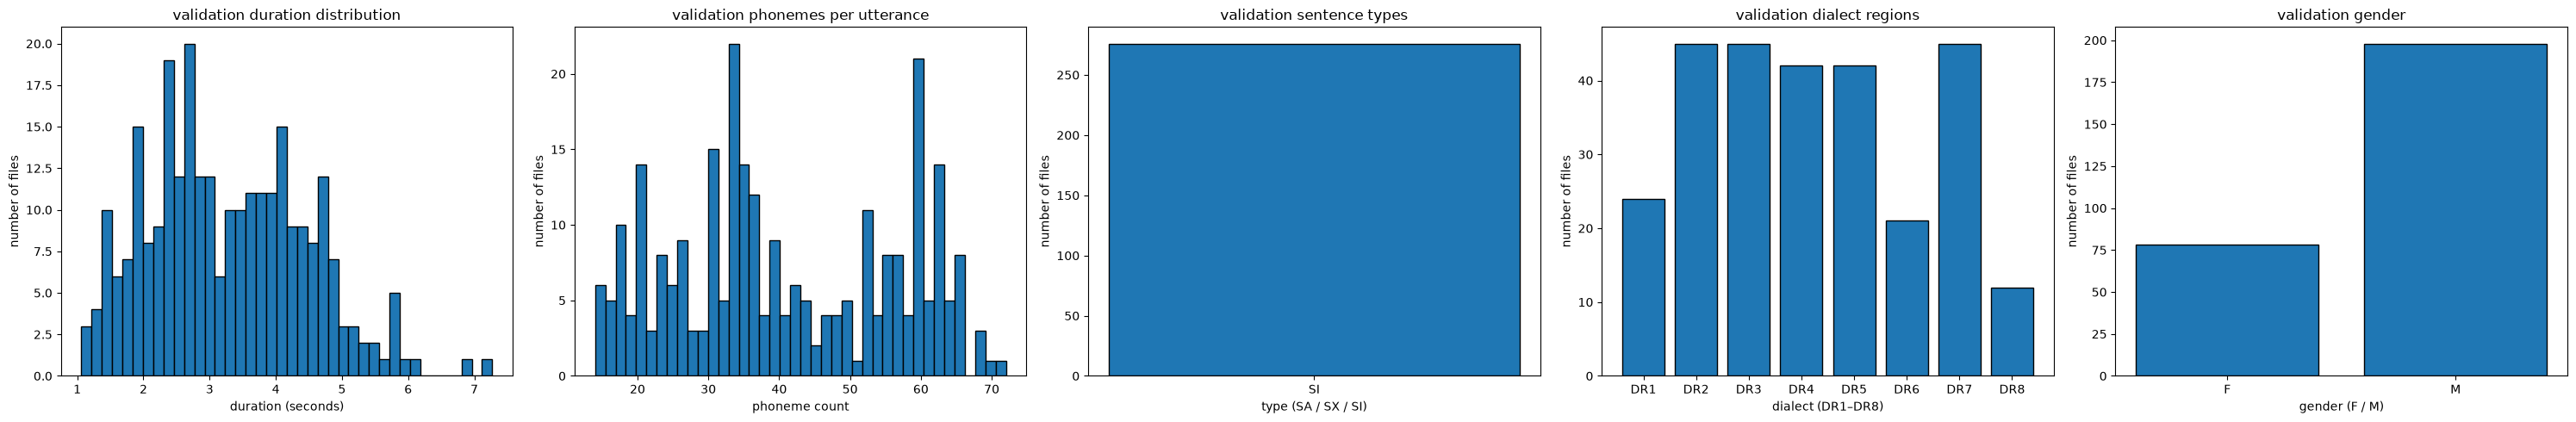

In [20]:
from sklearn.model_selection import StratifiedGroupKFold

timit_train_df = timit_train_df[timit_train_df["sentence_type"] != "SA"].copy()

timit_train_df["strat"] = timit_train_df["dialect_region"] + "_" + timit_train_df["gender"]
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train, val = next(sgkf.split(timit_train_df, timit_train_df["strat"], groups=timit_train_df["speaker_id"]))
timit_tr_df, timit_val_df = timit_train_df.iloc[train], timit_train_df.iloc[val]

timit_val_df = timit_val_df[timit_val_df["sentence_type"] == "SI"]

plot_timit_distributions(timit_tr_df, "train")
plot_timit_distributions(timit_val_df, "validation")

In [14]:
# from https://huggingface.co/blog/fine-tune-whisper
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import Any, Dict, List, Union

WHISPER_CKPT = "openai/whisper-small"
processor = WhisperProcessor.from_pretrained(WHISPER_CKPT)
model = WhisperForConditionalGeneration.from_pretrained(WHISPER_CKPT)

model.generation_config.language = "uk"
model.generation_config.task = "transcribe"
model.generation_config.forced_decoder_ids = None
model.freeze_encoder()

class TorontoDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.audio_dir = TORONTO
        self.sr = 16000 # whisper's input

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = self.audio_dir / row["speaker_id"] / row["filename"]
        audio, _ = librosa.load(path, sr=self.sr)                      

        input_features = self.processor(
            audio, sampling_rate=self.sr, return_tensors="pt"
        ).input_features[0]                                            
        labels = self.processor.tokenizer(row["label"]).input_ids

        return {"input_features": input_features, "labels": labels}


@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)

train_ds = TorontoDataset(toronto_tr_df, processor)
val_ds = TorontoDataset(toronto_val_df, processor)

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True,  collate_fn=data_collator)
val_dl = DataLoader(val_ds, batch_size=4, shuffle=False, collate_fn=data_collator)


batch = next(iter(train_dl))
print(batch["input_features"].shape, batch["labels"].shape)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

torch.Size([4, 80, 3000]) torch.Size([4, 53])


In [ ]:
import torch
import lightning as L
import evaluate
from lightning.pytorch.loggers import CSVLogger

class WhisperLightning(L.LightningModule):
    def __init__(self, model, processor, lr=1e-5):
        super().__init__()
        self.model = model
        self.processor = processor
        self.lr = lr
        self.wer = evaluate.load("wer")
        self.cer = evaluate.load("cer")

    def training_step(self, batch, _):
        loss = self.model(**batch).loss    
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)      
        return loss

    def validation_step(self, batch, _):
        out = self.model(**batch)
        self.log("val_loss", out.loss, prog_bar=True)

        pred_ids = self.model.generate(batch["input_features"], max_new_tokens=225)
        labels = batch["labels"].clone()
        labels[labels == -100] = self.processor.tokenizer.pad_token_id

        preds = self.processor.batch_decode(pred_ids, skip_special_tokens=True)
        refs  = self.processor.batch_decode(labels,  skip_special_tokens=True)

        self.wer.add_batch(predictions=preds, references=refs)
        self.cer.add_batch(predictions=preds, references=refs)

    def on_validation_epoch_end(self):
        self.log("val_wer", self.wer.compute(), prog_bar=True)
        self.log("val_cer", self.cer.compute(), prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.model.parameters(), lr=self.lr)

logger = CSVLogger("logs", name="whisper")
lit = WhisperLightning(model, processor)
trainer = L.Trainer(max_epochs=5, accelerator=device, logger=logger)
trainer.fit(lit, train_dl, val_dl)

m = pd.read_csv(f"{logger.log_dir}/metrics.csv")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

m.dropna(subset=["train_loss"]).plot(x="epoch", y="train_loss", marker="o", ax=ax1)
m.dropna(subset=["val_loss"]).plot(x="epoch", y="val_loss", marker="o", ax=ax1)
ax1.set_title("loss")

m.dropna(subset=["val_wer"]).plot(x="epoch", y="val_wer", marker="o", ax=ax2)
m.dropna(subset=["val_cer"]).plot(x="epoch", y="val_cer", marker="o", ax=ax2)
ax2.set_title("WER / CER")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                            ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model │ WhisperForConditionalGeneration │  241 M │ eval │     0 │
└───┴───────┴─────────────────────────────────┴────────┴──────┴───────┘

Trainable params: 153 M                                                                                            
Non-trainable params: 88.2 M                                                                                       
Total params: 241 M                                                                                                
Total estimated model params size (MB): 966.940                                                                    
Modules in train mode: 0                                                                                           
Modules in eval mode: 350                                                                                          
Total FLOPs: 0

Output()

/Users/neprog/mamba/envs/dl-audio-3/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

/Users/neprog/mamba/envs/dl-audio-3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connecto
r.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/Users/neprog/mamba/envs/dl-audio-3/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 350
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/Users/neprog/mamba/envs/dl-audio-3/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
PHONE_MAP = {
    "iy":"iy","ih":"ih","eh":"eh","ae":"ae","ix":"ih","ax":"ah","ah":"ah","ax-h":"ah",
    "uw":"uw","ux":"uw","uh":"uh","ao":"aa","aa":"aa","ey":"ey","ay":"ay","oy":"oy",
    "aw":"aw","ow":"ow","er":"er","axr":"er",
    "l":"l","el":"l","r":"r","w":"w","y":"y",
    "m":"m","em":"m","n":"n","nx":"n","en":"n","ng":"ng","eng":"ng",
    "v":"v","f":"f","dh":"dh","th":"th","z":"z","s":"s","zh":"sh","sh":"sh",
    "jh":"jh","ch":"ch","b":"b","p":"p","d":"d","t":"t","g":"g","k":"k","dx":"dx",
    "hh":"hh","hv":"hh",
    "bcl":"sil","pcl":"sil","dcl":"sil","tcl":"sil","gcl":"sil","kcl":"sil",
    "q":"sil","epi":"sil","pau":"sil","h#":"sil",
}

In [ ]:

timit_processor = WhisperProcessor.from_pretrained(WHISPER_CKPT)
timit_processor.tokenizer.add_tokens(PHONE_MAP.keys())                        
timit_processor.tokenizer.set_prefix_tokens(language="en", task="transcribe")

timit_model = WhisperForConditionalGeneration.from_pretrained(WHISPER_CKPT)
timit_model.resize_token_embeddings(len(timit_processor.tokenizer))
timit_model.freeze_encoder()

class TimitDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.sr = 16000

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        audio, _ = librosa.load(row["path"], sr=self.sr)

        input_features = self.processor(
            audio, sampling_rate=self.sr, return_tensors="pt"
        ).input_features[0]

        tok = self.processor.tokenizer
        phone_ids = tok.convert_tokens_to_ids(row["phonemes"])           
        labels = tok.prefix_tokens + phone_ids + [tok.eos_token_id]

        return {"input_features": input_features, "labels": labels}
    
timit_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=timit_processor,
    decoder_start_token_id=timit_model.config.decoder_start_token_id,
)

timit_train_ds = TimitDataset(timit_tr_df, timit_processor)
timit_val_ds = TimitDataset(timit_val_df, timit_processor)

timit_train_dl = DataLoader(timit_train_ds, batch_size=4, shuffle=True, collate_fn=timit_collator)
timit_val_dl  = DataLoader(timit_val_ds, batch_size=4, shuffle=False, collate_fn=timit_collator)

b = next(iter(timit_train_dl))
print(b["input_features"].shape, b["labels"].shape) 

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

torch.Size([4, 80, 3000]) torch.Size([4, 67])


In [ ]:
class TimitWhisperLightning(L.LightningModule):
    def __init__(self, model, processor, phone_map, lr=1e-5):
        super().__init__()
        self.model = model
        self.processor = processor
        self.phone_map = phone_map
        self.lr = lr
        self.per = evaluate.load("wer")

        tok = processor.tokenizer
        allowed = set(tok.convert_tokens_to_ids(list(phone_map.keys())))
        allowed |= set(tok.all_special_ids)
        self.allowed = sorted(allowed)

    def _fold(self, ids):
        toks = self.processor.tokenizer.convert_ids_to_tokens(ids)
        return " ".join(self.phone_map[t] for t in toks if t in self.phone_map)

    def training_step(self, batch, _):
        loss = self.model(**batch).loss
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        out = self.model(**batch)
        self.log("val_loss", out.loss, prog_bar=True)

        pred_ids = self.model.generate(
            batch["input_features"], max_new_tokens=225,
            prefix_allowed_tokens_fn=lambda b, ids: self.allowed,
        )
        labels = batch["labels"].clone()
        labels[labels == -100] = self.processor.tokenizer.pad_token_id 

        preds = [self._fold(p) for p in pred_ids.tolist()]
        refs  = [self._fold(l) for l in labels.tolist()]
        self.per.add_batch(predictions=preds, references=refs)

    def on_validation_epoch_end(self):
        self.log("val_per", self.per.compute(), prog_bar=True)

    def configure_optimizers(self):
        params = filter(lambda p: p.requires_grad, self.model.parameters())
        return torch.optim.AdamW(params, lr=self.lr)

timit_lit = TimitWhisperLightning(timit_model, timit_processor, PHONE_MAP)
timit_logger = CSVLogger("logs", name="whisper_timit")
timit_trainer = L.Trainer(max_epochs=5, accelerator=device, logger=timit_logger)
timit_trainer.fit(timit_lit, timit_train_dl, timit_val_dl)

m = pd.read_csv(f"{timit_logger.log_dir}/metrics.csv")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
m.dropna(subset=["train_loss"]).plot(x="epoch", y="train_loss", marker="o", ax=ax1)
m.dropna(subset=["val_loss"]).plot(x="epoch", y="val_loss", marker="o", ax=ax1)
ax1.set_title("loss")
m.dropna(subset=["val_per"]).plot(x="epoch", y="val_per", marker="o", ax=ax2)
ax2.set_title("PER")
plt.show()